<a href="https://colab.research.google.com/github/Feemoai/Sinyal-dan-Sistem-Kontrol-Elektronik/blob/main/BAB_V_Analisis_Data_Sistem_Kontrol_ESP32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BAB V - Analisis Data Sistem Kontrol ESP32


In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FOLDER = "sample_data"
TS = 0.5

# kode, nama file, Kp, Ki
percobaan = [
    ("P1", "p1_sp20.csv", 1, 0.1),
    ("P2", "p2_sp15.csv", 1, 0.1),
    ("P3", "p3_sp10.csv", 1, 0.1),
    ("P4", "p4_P.csv",    1, 0),
    ("P5", "p5_Kp2.csv",  2, 0),
    ("P6", "p6_Ki03.csv", 1, 0.3),
    ("P7", "p7_Ki05.csv", 1, 0.5),
]

## 1. Fungsi perhitungan metrik

Yang dianalisis adalah langkah set point **terakhir** di tiap file (misalnya 2,5 V turun ke 1,5 V).
Toleransi settling ±2% dari SP, dengan batas minimum 0,03 V (karena noise ADC dan resolusi DAC 8-bit).

In [31]:
def cari_langkah(df):
    sp = df["sp_V"].values
    mulai = 0
    for i in range(1, len(sp)):
        if abs(sp[i] - sp[i-1]) > 1e-6:
            mulai = i
    return mulai


def waktu_lewat(t, pv, level, arah):
    for i in range(1, len(pv)):
        a = pv[i-1]
        b = pv[i]
        if (a - level) * arah < 0 and (b - level) * arah >= 0:
            return t[i-1] + (level - a) / (b - a) * (t[i] - t[i-1])
    return None


def analisis(df):
    mulai = cari_langkah(df)
    if mulai == 0:
        return None

    t = df["t_s"].values[mulai:] - df["t_s"].values[mulai]
    pv = df["pv_V"].values[mulai:]
    sp1 = df["sp_V"].values[mulai]
    sp0 = pv[0]
    d = sp1 - sp0
    if d > 0:
        arah = 1
    else:
        arah = -1

    # overshoot
    if arah > 0:
        puncak = pv.max()
    else:
        puncak = pv.min()
    mp = max(0, arah * (puncak - sp1) / sp1 * 100)

    # rise time 10% ke 90%
    t10 = waktu_lewat(t, pv, sp0 + 0.1 * d, arah)
    t90 = waktu_lewat(t, pv, sp0 + 0.9 * d, arah)
    tr = None
    if t10 is not None and t90 is not None:
        tr = t90 - t10

    # settling time
    tol = max(0.02 * abs(sp1), 0.03)
    terakhir_luar = -1
    for i in range(len(pv)):
        if abs(pv[i] - sp1) > tol:
            terakhir_luar = i
    ts = None
    if terakhir_luar < len(pv) - 1 and len(pv) >= 10:
        ts = t[terakhir_luar + 1]

    # steady-state error dari rata-rata 5 sampel terakhir
    pv_akhir = pv[-5:].mean()
    ess = sp1 - pv_akhir

    # waktu mencapai keadaan tunak (relatif ke nilai akhirnya sendiri)
    idx = 0
    for i in range(len(pv)):
        if abs(pv[i] - pv_akhir) > 0.03:
            idx = i + 1
    if idx >= len(t):
        idx = len(t) - 1
    t_tunak = t[idx]

    # fluktuasi di bagian akhir (indikator kestabilan)
    std_akhir = pv[-20:].std()

    return {"sp0": sp0, "sp1": sp1, "mp": mp, "tr": tr, "ts": ts,
            "ess": ess, "pv_akhir": pv_akhir, "t_tunak": t_tunak,
            "std_akhir": std_akhir, "t": t, "pv": pv}

## 2. Hitung semua percobaan

In [32]:
data = {}
baris = []

for kode, nama, kp, ki in percobaan:
    path = os.path.join(FOLDER, nama)
    if not os.path.exists(path):
        print(kode, nama, "-> file tidak ditemukan")
        continue
    df = pd.read_csv(path)
    while len(df) > 10 and df["dac_V"].iloc[-1] < 0.01:
        df = df.iloc[:-1]
    h = analisis(df)
    if h is None:
        print(kode, nama, "-> tidak ada perubahan set point di data")
        continue
    h["label"] = "%s (Kp %s, Ki %s)" % (kode, kp, ki)
    data[kode] = h
    baris.append({
        "Percobaan": kode,
        "File": nama,
        "SP awal (V)": h["sp0"],
        "SP akhir (V)": h["sp1"],
        "Kp": kp,
        "Ki": ki,
        "Mp (%)": h["mp"],
        "Rise time (s)": h["tr"],
        "Settling (s)": h["ts"],
        "e_ss (V)": h["ess"],
        "PV akhir (V)": h["pv_akhir"],
        "t tunak (s)": h["t_tunak"],
        "Std akhir (V)": h["std_akhir"],
    })

hasil = pd.DataFrame(baris)
hasil.round(3)

,Percobaan,File,SP awal (V),SP akhir (V),Kp,Ki,Mp (%),Rise time (s),Settling (s),e_ss (V),PV akhir (V),t tunak (s),Std akhir (V)
0,P1,p1_sp20.csv,2.502,2.0,1,0.1,1.100,27.058,31.0,0.003,1.997,33.0,0.004
1,P2,p2_sp15.csv,2.494,1.5,1,0.1,2.867,26.557,65.0,0.007,1.493,64.6,0.005
2,P3,p3_sp10.csv,2.505,1.0,1,0.1,7.700,26.086,77.0,0.013,0.987,68.0,0.005
3,P4,p4_P.csv,2.623,1.5,1,0.0,0.000,NaN,NaN,-0.685,2.185,25.5,0.004
4,P5,p5_Kp2.csv,2.591,1.5,2,0.0,0.000,NaN,NaN,-0.478,1.978,20.5,0.004
5,P6,p6_Ki03.csv,2.499,1.5,1,0.3,15.200,11.544,63.5,0.002,1.498,64.0,0.004
6,P7,p7_Ki05.csv,2.500,1.5,1,0.5,20.667,8.383,64.5,0.002,1.498,64.5,0.003


Cara membaca tabel:
- **Settling kosong (NaN)** artinya PV tidak pernah masuk dan bertahan di pita ±2% SP. Biasanya karena steady-state error besar (pengendali P saja).
- **Rise time kosong** artinya PV tidak pernah mencapai 90% dari lompatan.
- **t tunak** adalah waktu PV berhenti berubah (di dalam ±0,03 V dari nilai akhirnya sendiri). Pakai ini untuk membandingkan kecepatan respons yang punya e_ss, dan beri label jelas di laporan bahwa ini metrik tambahan.
- **Std akhir** besar berarti PV masih bergoyang di bagian akhir (kurang stabil atau noise).

In [33]:
hasil.round(3).to_csv("hasil_metrik.csv", index=False)
print("tabel disimpan ke hasil_metrik.csv")

tabel disimpan ke hasil_metrik.csv


## 3. Grafik perbandingan

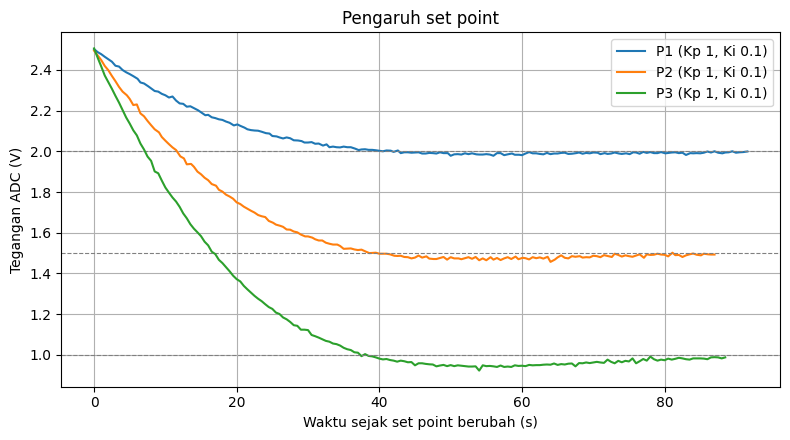

In [34]:
def grafik(judul, daftar_kode, nama_png):
    plt.figure(figsize=(8, 4.5))
    for kode in daftar_kode:
        if kode not in data:
            continue
        h = data[kode]
        plt.plot(h["t"], h["pv"], label=h["label"])
        plt.axhline(h["sp1"], color="gray", linestyle="--", linewidth=0.8)
    plt.xlabel("Waktu sejak set point berubah (s)")
    plt.ylabel("Tegangan ADC (V)")
    plt.title(judul)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(nama_png, dpi=200)
    plt.show()


grafik("Pengaruh set point", ["P1", "P2", "P3"], "grafik_setpoint.png")

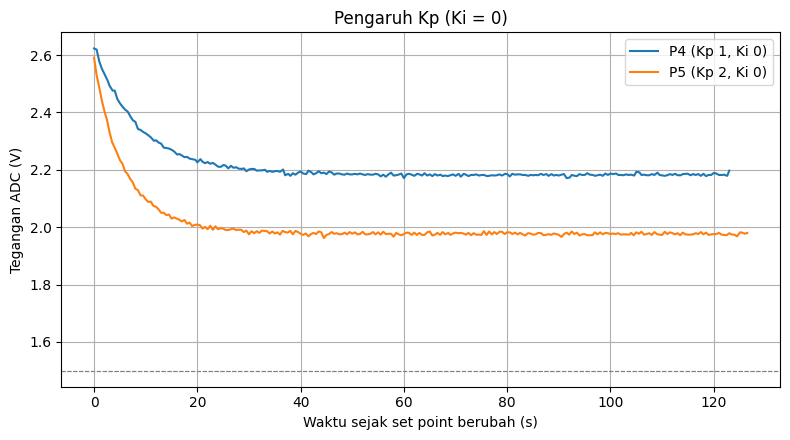

In [35]:
grafik("Pengaruh Kp (Ki = 0)", ["P4", "P5"], "grafik_kp.png")

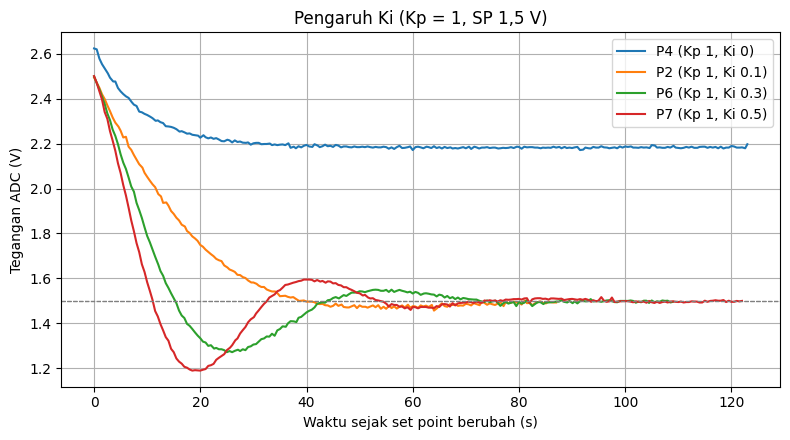

In [36]:
grafik("Pengaruh Ki (Kp = 1, SP 1,5 V)", ["P4", "P2", "P6", "P7"], "grafik_ki.png")

## 4. Grafik lengkap satu percobaan (untuk Bab 4)

Menampilkan Set Point, ADC, dan output DAC dari seluruh data CSV.

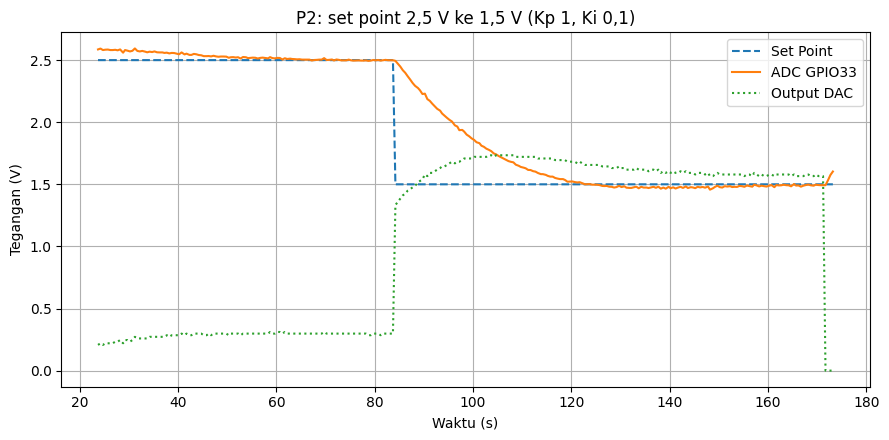

In [37]:
def grafik_penuh(nama, judul):
    df = pd.read_csv(os.path.join(FOLDER, nama))
    plt.figure(figsize=(9, 4.5))
    plt.plot(df["t_s"], df["sp_V"], "--", label="Set Point")
    plt.plot(df["t_s"], df["pv_V"], label="ADC GPIO33")
    plt.plot(df["t_s"], df["dac_V"], ":", label="Output DAC")
    plt.xlabel("Waktu (s)")
    plt.ylabel("Tegangan (V)")
    plt.title(judul)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("penuh_" + nama.replace(".csv", ".png"), dpi=200)
    plt.show()


grafik_penuh("p2_sp15.csv", "P2: set point 2,5 V ke 1,5 V (Kp 1, Ki 0,1)")